In [ ]:
# %pip install matplotlib
# %pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
start_year = str(input("Enter start year: "))
end_year = str(input("Enter end year: "))

In [6]:
import pandas as pd

# Load the parquet file
df = pd.read_parquet(f"../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_{start_year}-{end_year}.parquet")

# View the first 5 rows
print(df.head())

             file_id  year                                          case_name  \
0  2020_10_1043_1074  2020  M/S. L. R. BROTHERS INDO FLORA LTD. versus COM...   
1  2020_10_1075_1131  2020  M/S BANDEKAR BROTHERS PVT. LTD. & ANR versus P...   
2  2020_10_1132_1150  2020  THE NEW INDIA ASSURANCE COMPANY LIMITED versus...   
3    2020_10_135_237  2020         VINEETA SHARMA versus RAKESH SHARMA & ORS.   
4       2020_10_1_26  2020          BCH ELECTRIC LIMITED versus PRADEEP MEHRA   

                                           full_text  \
0  M/S. L. R. BROTHERS INDO FLORA LTD.\nv.\nCOMMI...   
1  M/S BANDEKAR BROTHERS PVT. LTD. & ANR\nv.\nPRA...   
2  THE NEW INDIA ASSURANCE COMPANY LIMITED\nv.\nS...   
3  VINEETA SHARMA\nv.\nRAKESH SHARMA & ORS.\n(Civ...   
4  BCH ELECTRIC LIMITED\nv.\nPRADEEP MEHRA\n(Civi...   

                                          precedents  \
0  [Union of India & Anr. v. IndusInd Bank Limite...   
1  [In Dr. S. Dutt v. State of Uttar Pradesh, Nar...   
2  [Sang

In [7]:
numcase = 60

In [8]:
print(df.iloc[numcase].T)

file_id                                             2020_12_1118_1132
year                                                             2020
case_name           ANITA SHARMA & ORS. versus THE NEW INDIA ASSUR...
full_text           ANITA SHARMA & ORS.\nv.\nTHE NEW INDIA ASSURAN...
precedents          [National Insurance Co Ltd v. Pranay Sethi, Co...
coram                                     SURYA KANT*, ANIRUDDHA BOSE
decision_date                                              08-12-2020
case_no                                    CIVIL APPEAL No. 4010/2020
disposal_nature                                   Case Partly allowed
neutral_citation                                          2020INSC685
Name: 60, dtype: object


In [9]:
filename = df.loc[numcase, "file_id"]
print(filename)

caseName = df.loc[numcase, 'case_name']
print(caseName)

2020_12_1118_1132
ANITA SHARMA & ORS. versus THE NEW INDIA ASSURANCE CO. LTD. & ANR.


In [10]:
value = df.loc[numcase, 'precedents']
print(value)

['National Insurance Co Ltd v. Pranay Sethi'
 'Court in Parmeshwari v. Amir Chand1'
 'Constitution Bench in Kartar Singh v. State of Punjab2'
 'MACT case this Court in Sunita v. Rajasthan State Road Transport Corporatio'
 'Dulcina Fernandes v. Joaquim Xavier Cruz'
 'Kartar Singh v. State of Punjab' 'Parmeshwari v. Amir Chand'
 'Bimla Devi v. Himachal RTC'
 'Court in National Insurance Co Ltd v. Pranay Sethi5'
 'Dulcina Fernandes v. Joaquim Xavier Cruz4 wherein this Court r'
 'Sunita v. Rajasthan State Road Transport Corporatio']


In [ ]:
print(f"Loaded {len(df)} records with {df.shape[1]} columns")


✅ Loaded 4368 records with 10 columns



--- Missing Values (Top 15) ---
disposal_nature     3.30
coram               0.21
year                0.00
file_id             0.00
full_text           0.00
case_name           0.00
precedents          0.00
decision_date       0.00
case_no             0.00
neutral_citation    0.00
dtype: float64


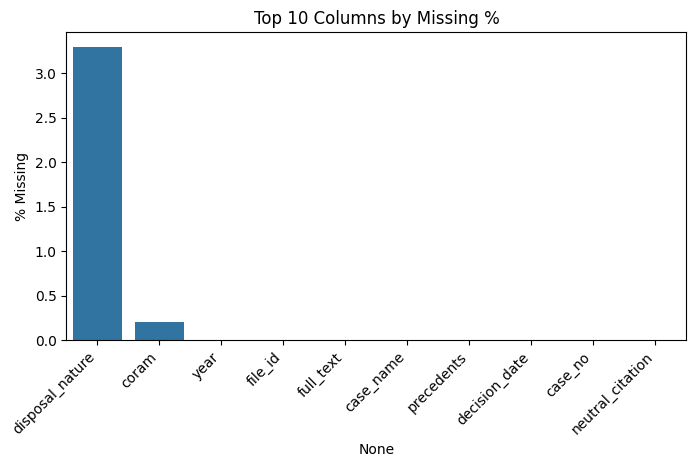

In [ ]:
# Missing value audit
print("\n--- Missing Values (Top 15) ---")
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(15).round(2))

plt.figure(figsize=(8,4))
sns.barplot(x=missing.head(10).index, y=missing.head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Columns by Missing %")
plt.ylabel("% Missing")
plt.show()


--- Disposal Nature  Distribution ---
disposal_nature
Appeal(s) allowed                  1976
Dismissed                           989
Disposed off                        728
Case Partly allowed                 276
None                                144
Directions issued                   119
Case Allowed                         46
Reference answered                   32
Matter referred to larger bench      30
Leave Granted & Allowed              12
Leave Granted & Dismissed             7
Rejected                              5
Remitted to Lower Court               1
Leave Granted & Disposed off          1
Dismissed as withdrawn                1
IA disposed                           1
Name: count, dtype: int64


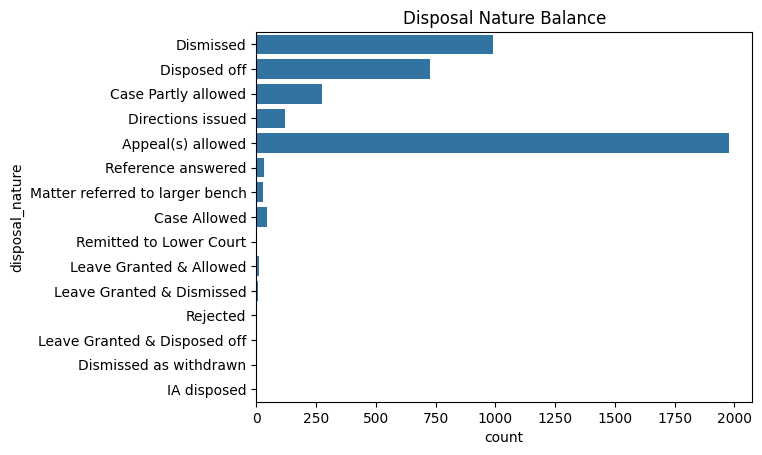

In [16]:
# Data completeness & label balance
print("\n--- Disposal Nature  Distribution ---")
print(df['disposal_nature'].value_counts(dropna=False))
sns.countplot(y='disposal_nature', data=df)
plt.title("Disposal Nature Balance")
plt.show()


--- Text Length Stats ---
count      4368.00
mean       8621.33
std       11462.49
min         180.00
25%        3305.00
50%        5447.50
75%        9387.25
max      150358.00
Name: text_len, dtype: float64


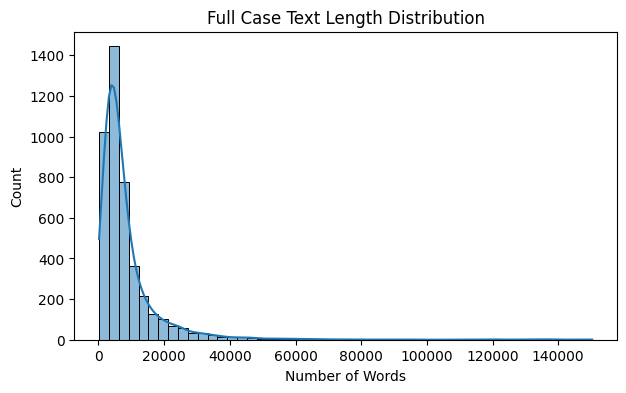

In [15]:
# =======================================
# 4️⃣ Text quality metrics
# =======================================
print("\n--- Text Length Stats ---")
df['text_len'] = df['full_text'].apply(lambda x: len(str(x).split()))
print(df['text_len'].describe().round(2))

plt.figure(figsize=(7,4))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title("Full Case Text Length Distribution")
plt.xlabel("Number of Words")
plt.show()

In [ ]:
# 1. Explode the 'acts' column so each Act gets its own row
df_exploded = df.explode('acts')

# 2. Drop rows where 'acts' might be None (cases with no identified laws)
df_exploded = df_exploded.dropna(subset=['acts'])

# 3. Calculate the Top 10 Acts for a readable plot
top_10_acts = df_exploded['acts'].value_counts().nlargest(10)

print("\n--- Top 10 Acts/Articles Distribution ---")
print(top_10_acts)

# 4. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_acts.values, y=top_10_acts.index, palette='viridis')

plt.title("Top 10 Most Cited Acts & Articles (2020-2025)")
plt.xlabel("Number of Cases")
plt.ylabel("Act / Article")
plt.tight_layout()
plt.show()